# Vaccinations RCT

In [1]:
import polars as pl
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.api as sm

## Calculating vaccine efficacy
Vaccine efficacy:
$$
\operatorname{VE} = \frac{\text{Risk for Unvaccianted - Risk for Vaccinated}}{\text{Risk for Unvaccianted}}.
$$
Checking how FDA approval works, I should use surveillance time instead of the simple participant headcount $(n2^d)$ because it accounts for the exact amount of time each person was actually at risk of infection. In a rolling clinical trial, participants enroll on different dates, and some may drop out or catch the virus earlier than others.

In [2]:
# Create a dataframe with vaccination data
df = pl.DataFrame({
    'Age Group': ['16-17', '18-64', '65-74', '75+'],
    'SV': [0.003, 1.799, 0.424, 0.106], # SV = surveillance time vaccinated
    'SU': [0.003, 1.811, 0.423, 0.109], # SU = surveillance time unvaccinated
    'NV': [58, 14443, 3239, 805], # NV = number of vaccinated
    'NU': [61, 14566, 3255, 812], # NU = number of unvaccinated
    'IV': [0, 8, 1, 0], # IV = number of incidents vaccinated
    'IU': [1, 149, 14, 6] # IU = number of incidents unvaccinated
})

# Calculate vaccine efficacy (VE)
df = df.with_columns(
    (pl.col("IV") / pl.col("SV")).alias("RV"), # RV = risk vaccinated
    (pl.col("IU") / pl.col("SU")).alias("RU"), # RU = risk unvaccinated
    (pl.col("IV") / pl.col("NV")).alias("PV"), # PV = probability infection vaccinated
    (pl.col("IU") / pl.col("NU")).alias("PU"), # PU = probability infection unvaccinated
    ).with_columns(
        ((pl.col("RU")-pl.col("RV"))/pl.col("RU")).alias("VE"), # VE = vaccine effectiveness
        ((pl.col("PU")-pl.col("PV"))/pl.col("PU")).alias("VE_approx"), # approximate vaccine effectiveness
    )

print(df)

print("Vaccine efficacy for 18-64 age group:", df.filter(pl.col("Age Group") == "18-64")["VE"].round(3).item())

shape: (4, 13)
┌───────────┬───────┬───────┬───────┬───┬──────────┬──────────┬──────────┬───────────┐
│ Age Group ┆ SV    ┆ SU    ┆ NV    ┆ … ┆ PV       ┆ PU       ┆ VE       ┆ VE_approx │
│ ---       ┆ ---   ┆ ---   ┆ ---   ┆   ┆ ---      ┆ ---      ┆ ---      ┆ ---       │
│ str       ┆ f64   ┆ f64   ┆ i64   ┆   ┆ f64      ┆ f64      ┆ f64      ┆ f64       │
╞═══════════╪═══════╪═══════╪═══════╪═══╪══════════╪══════════╪══════════╪═══════════╡
│ 16-17     ┆ 0.003 ┆ 0.003 ┆ 58    ┆ … ┆ 0.0      ┆ 0.016393 ┆ 1.0      ┆ 1.0       │
│ 18-64     ┆ 1.799 ┆ 1.811 ┆ 14443 ┆ … ┆ 0.000554 ┆ 0.010229 ┆ 0.945951 ┆ 0.945851  │
│ 65-74     ┆ 0.424 ┆ 0.423 ┆ 3239  ┆ … ┆ 0.000309 ┆ 0.004301 ┆ 0.92874  ┆ 0.928219  │
│ 75+       ┆ 0.106 ┆ 0.109 ┆ 805   ┆ … ┆ 0.0      ┆ 0.007389 ┆ 1.0      ┆ 1.0       │
└───────────┴───────┴───────┴───────┴───┴──────────┴──────────┴──────────┴───────────┘
Vaccine efficacy for 18-64 age group: 0.946


The df["VE"] column calculates vaccine efficacy based on the true incidence rate, utilizing surveillance time instead of a simple headcount. To achieve this, the code first computes the "risk vaccinated" (RV) by dividing the number of incidents in the vaccinated group (IV) by their total surveillance time (SV). Similarly, it computes the "risk unvaccinated" (RU) by dividing the unvaccinated incidents (IU) by their surveillance time (SU). Finally, the vaccine efficacy (VE) is calculated by taking the difference between the unvaccinated and vaccinated risks, and dividing it by the unvaccinated risk using the formula (RU - RV) / RU.

Use probability of infection to proxy the treatment effect.

In [3]:
print(f"Incidence per 100000 among treated: {df['PV'][1] * 100000:.4f}")
print(f"Incidence per 100000 among controlled: {df['PU'][1] * 100000:.4f}")

# treatment effect: estimated reduction in incidence per 100k people
effect = 100000 * (df["PV"] - df["PU"])[1] # index 1 corresponds to 18-64 age group

print(f"Estimate of effect on occurances per 100,000: {effect:.2f}")

var_rv = df["PV"] * (1 - df["PV"]) / df["NV"]
var_ru = df["PU"] * (1 - df["PU"]) / df["NU"]
var_effect = (100000**2) * (var_rv + var_ru)
std_effect = np.sqrt(var_effect)[1] # index 1 corresponds to 18-64 age group

print(f"Standard error for ATE is: {std_effect:.2f}")

ci_effect = [effect - 1.96 * std_effect, effect + 1.96 * std_effect]

print(f"95% confidence interval is [{ci_effect[0]:.4f}, {ci_effect[1]:.4f}]")

Incidence per 100000 among treated: 55.3902
Incidence per 100000 among controlled: 1022.9301
Estimate of effect on occurances per 100,000: -967.54
Standard error for ATE is: 85.64
95% confidence interval is [-1135.3941, -799.6859]


## Bootstrap confidence intervals

Use bootstrapping to get confidence intervals for vaccine efficacy. We implement an approximate (parametric) bootstrap rather than standard resampling from the raw data since the latter is not available to us.

First, we take the calculated probabilities of infection (PV and PU) and their respective variances (var_rv and var_ru) for the 18-64 age group. We then simulate 10,000 random samples for both the vaccinated and unvaccinated risks by drawing from a normal (binomial) distribution centered on those probabilities and scaled by their standard errors (with the parameters from the trial). Finally, the code calculates the simulated vaccine efficacy (VEs) for each of the 10,000 random draws and determines the 95% confidence interval by extracting the 2.5th and 97.5th percentiles from this resulting distribution.

### Approximate normal bootstrap

95% confidence interval of VE is [0.9056, 0.9830]


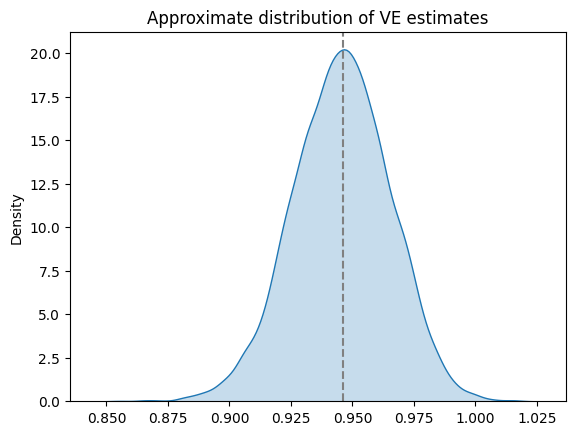

In [4]:
PV = df["PV"][1] # index 1 corresponds to 18-64 age group
PU = df["PU"][1]
np.random.seed(123)
B = 10000
RVs = PV + np.random.normal(0, 1, B) * np.sqrt(var_rv[1]) # index 1 corresponds to 18-64 age group
RUs = PU + np.random.normal(0, 1, B) * np.sqrt(var_ru[1])
VEs = (RUs - RVs) / RUs

CI_VE = np.quantile(VEs, (.025, .975))

print(f"95% confidence interval of VE is [{CI_VE[0]:.4f}, {CI_VE[1]:.4f}]")
plt.axvline(x=df.filter(pl.col("Age Group") == "18-64")["VE"].item(), color='grey', linestyle='--')
sns.kdeplot(VEs, fill=True)

plt.title("Approximate distribution of VE estimates")
plt.show()

### Binomial parametric bootstrap

Two-sided 95% confidence interval of VE is [0.9043, 0.9803]
One-sided 95% confidence interval of VE is [0.9118, 1]


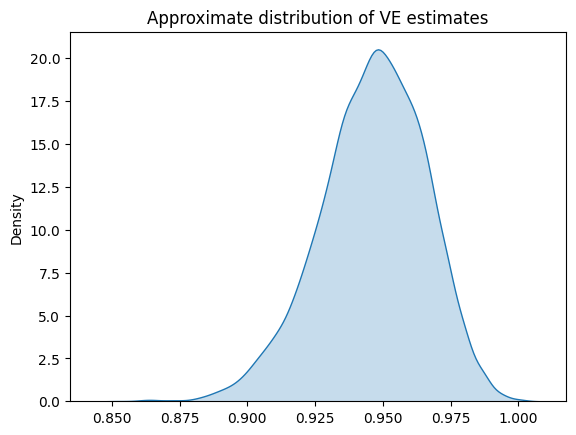

In [5]:
NV = df["NV"][1] # index 1 corresponds to 18-64 age group
NU = df["NU"][1]

np.random.seed(123)
B = 10000
RVs = np.random.binomial(NV, PV, size=B) + 1e-10
RUs = np.random.binomial(NU, PU, size=B) + 1e-10
VEs = (RUs - RVs) / RUs

CI_VE = np.quantile(VEs, (.025, .975))

print(f"Two-sided 95% confidence interval of VE is [{CI_VE[0]:.4f}, {CI_VE[1]:.4f}]")

CI_VE = np.quantile(VEs, (.05))

print(f"One-sided 95% confidence interval of VE is [{CI_VE:.4f}, 1]")


sns.kdeplot(VEs, fill=True)
plt.title("Approximate distribution of VE estimates")
plt.show()

The confidence interval based on Binomial bootstrap is slightly more accurate which makes sense since the outcomes are Bernoulli random variables.

## Contingency table
We approximate the log of the risks by a normal distribution, construct confidence intervals for the quantity $\log(PV) - \log(PU)$ and then invert. 

In [6]:
tb = sm.stats.Table2x2([[8, 14443 - 8], [149, 14566 - 149]])

print(f"Overall vaccine efficacy is {1 - tb.riskratio:.4f}")
lb, ub = tb.riskratio_confint(alpha=.05)
print(f"Approximate 95% confidence interval of VE: [{1 - ub:.4f}, {1 - lb:.4f}]")

Overall vaccine efficacy is 0.9459
Approximate 95% confidence interval of VE: [0.8898, 0.9734]


This procedure is even more accurately matching the FDA's table. By using the exact mathematical properties of proportions rather than relying on the random draw of discrete rare events, the contingency table approach provides a stable, mathematically sound confidence interval that doesn't struggle from the imbalance in the event counts.